# Realistic DOT-EEG Data with Synthetic Ground Truth


In [2]:
import sys
import numpy as np
from pathlib import Path
import pandas as pd
import mne
import mne.bem
import xarray as xr
import matplotlib.pyplot as plt
import os
import pyvista as pv
import trimesh
import nibabel as nib
import json
from scipy.spatial import cKDTree

import cedalion
import cedalion.sim
from cedalion import units
from cedalion.dataclasses import PointType
import cedalion.dataclasses as cdc

from cedalion.sim.synthetic_dot import SimulatefNIRSAndEEGData
from cedalion.sim.utils_plots import plot_fnirs, plot_eeg
import cedalion.sim.forward_model_local as fw  # local version of forward_model, to allow modifications
from cedalion.sim.source_simulator import SourcesConfig, SourceSpec

plt.switch_backend('ipympl')

# To reaload packages and modules automatically! Super useful to avoid double coding
%load_ext autoreload
%autoreload 2

## Initialize Simulation Class

In [3]:
# Define global paths
SUBJECTS_DIR = Path("/Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data")
subject = 'de179'
sub_dir = SUBJECTS_DIR / subject

# Initialize class
sim = SimulatefNIRSAndEEGData(subject=subject,
                              subjects_dir=SUBJECTS_DIR,
                              verbose=True,
                              seed=None)

Random seed set to 272551.
Initialized SimulatefNIRSAndEEGData for subject de179 in /Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data/de179.


## Background Data


--- Loading FNIRS and EEG background data ---
Opening raw data file /Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data/de179/de179_rest1_eeg_raw.fif...
Isotrak not found
    Range : 222990 ... 290334 =    447.011 ...   582.010 secs
Ready.
Reading 0 ... 67344  =      0.000 ...   134.999 secs...
fNIRS background data time range: 0.13 s to 134.90 s
EEG background data time range: 0.00 s to 135.00 s
--- fNIRS and EEG background data loaded Successfully ---

--- Defining resting state period ---
-- Resting state period defined from 10 second to 120 second --


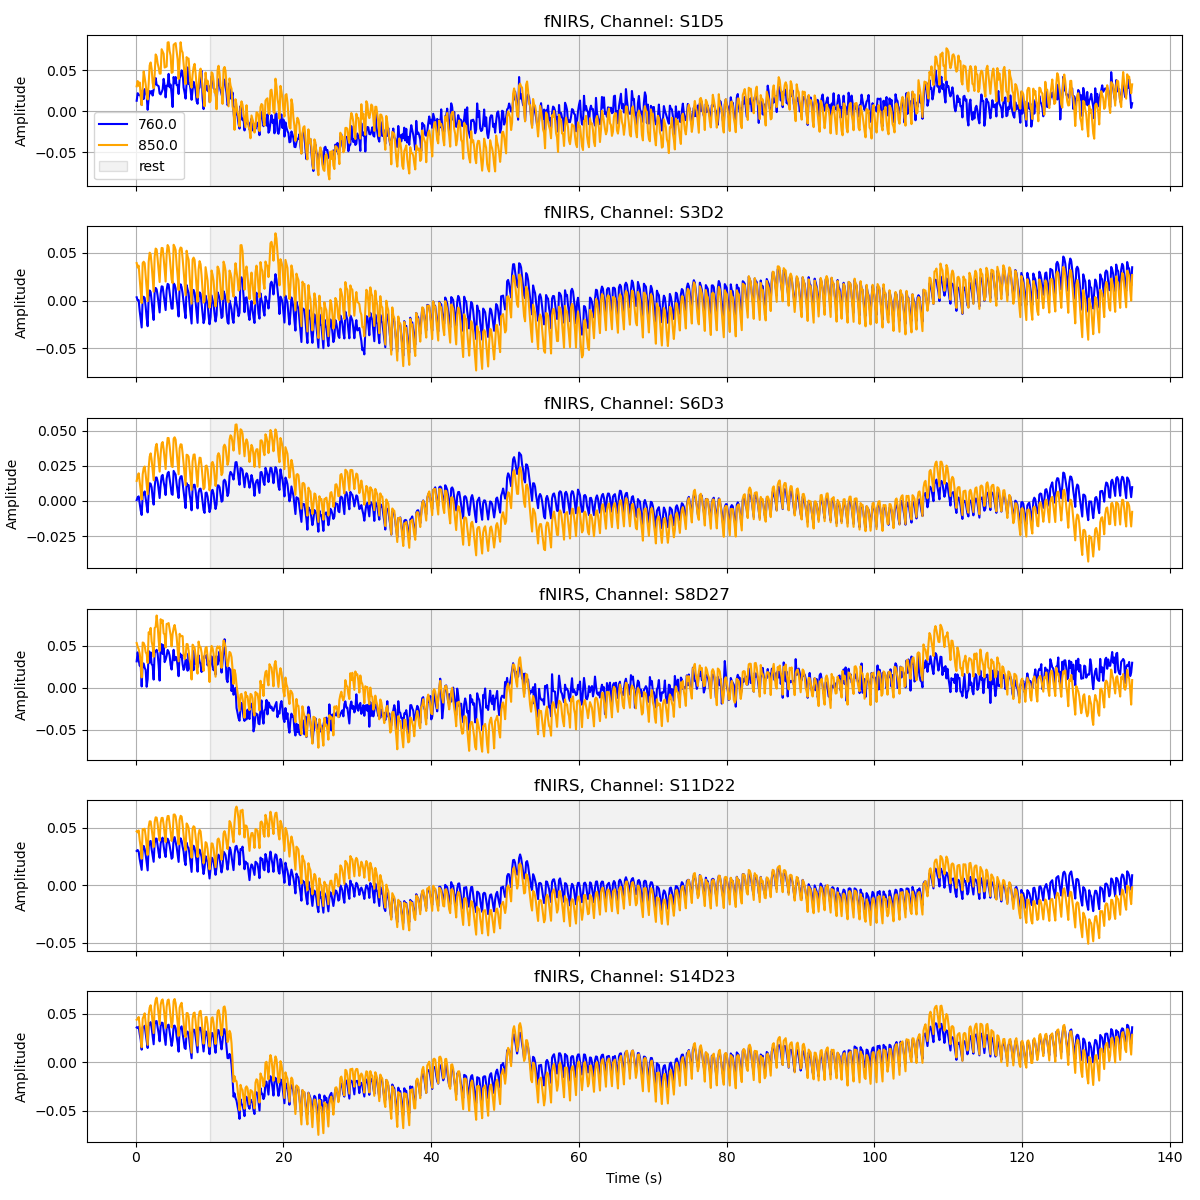

Using matplotlib as 2D backend.


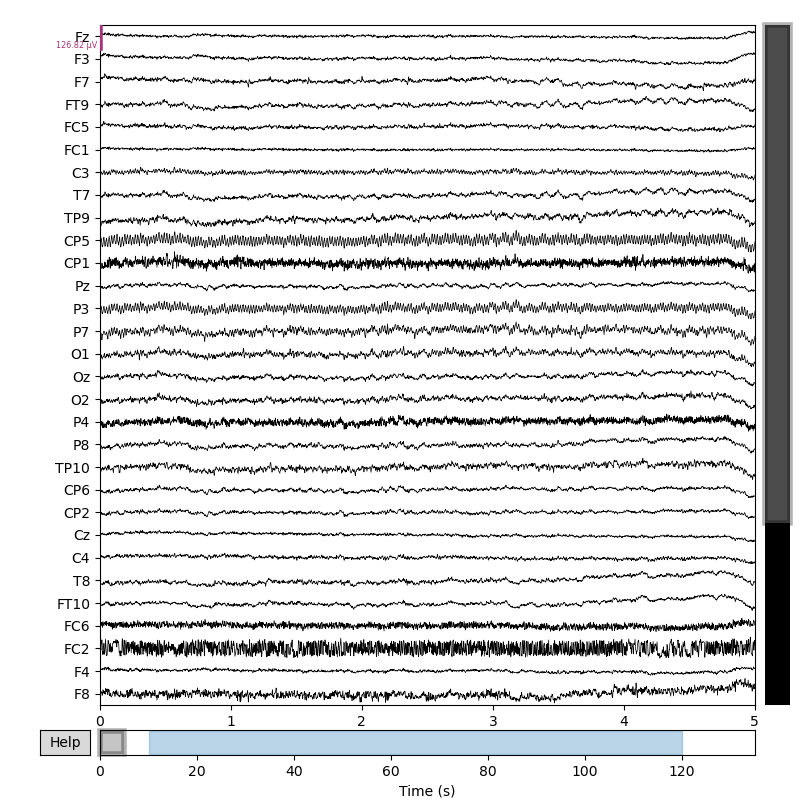

Effective window size : 4.105 (s)
Plotting power spectral density (dB=True).


/Users/guybrush/Documents/neurotech/cedalion/src/cedalion/sim/utils_plots.py:89: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  eeg_raw.compute_psd(fmax=fmax).plot()


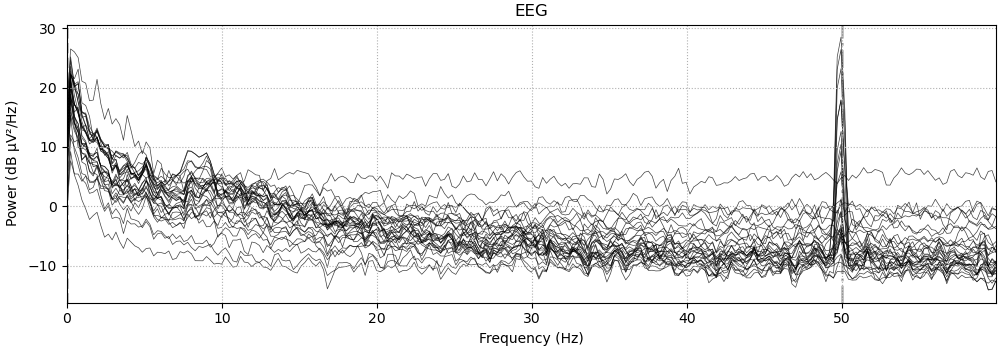

In [4]:
# fnirs and eeg background files
rest_ndx = 1
fnirs_background_file = sub_dir / f'{subject}_rest{rest_ndx}_nirs.snirf'  # fNIRS
eeg_background_file = sub_dir / f'{subject}_rest{rest_ndx}_eeg_raw.fif'  # EEG

# Load background data
sim.load_background_data(fnirs_file=fnirs_background_file, 
                         eeg_file=eeg_background_file,
                         rest_window=(10, 120))

# Visualize background data and montage
fnirs_ch_plot = sim.fnirs_bg_rec['amp'].channel.values[::20]
plot_fnirs(sim.fnirs_bg_rec['od'], channels=fnirs_ch_plot, stim=sim.rest_stim, fmt=sim.fmt)
plot_eeg(sim.eeg_bg_raw, plot_psd=True, fmax=60)

## Head Model and Montage

In [5]:
# Headmodel files
headmodel_name = 'colin27'  # 'colin27' or 'individual'
headmodel_dir = sub_dir / 'headmodel'
segmentation_masks = {
    'skull': 'mask_bone.nii',
    'scalp': 'mask_skin.nii',
    'gm': 'mask_gray.nii',
    'wm': 'mask_white.nii',
    'csf': 'mask_csf.nii'
}
brain_surface_file = headmodel_dir / 'mask_brain.obj'
scalp_surface_file = headmodel_dir / 'mask_scalp.obj'
landmarks_ras_file = headmodel_dir / 'headmodel_landmarks.mrk.json'
parcel_file = headmodel_dir / 'parcels.json'

# Build head model and fNIRS-EEG montage profile, the latter already aligned and snapped to scalp
sim.build_headmodel(head_model_name=headmodel_name, 
                            segmentation_dir=headmodel_dir,
                            mask_files=segmentation_masks,
                            brain_surface_file=brain_surface_file,
                            scalp_surface_file=scalp_surface_file,
                            landmarks_ras_file=landmarks_ras_file,
                            brain_face_count=None,
                            scalp_face_count=None,
                            brain_seg_types=['gm', 'wm'],
                            scalp_seg_types=['scalp'],
                            smoothing=0.5,
                            fill_holes=True,
                            parcel_file=parcel_file)


# Build fNIRS-EEG montage
montage_file = sub_dir / f'{subject}_fnirs_montage_global.tsv'

montage = sim.build_montage(montage_file=montage_file,
                  eeg_montage_name='standard_1020')

# Visualize head model and montage
sim.plot_surfaces(plot_montage=True,
                  plot_brain=True,
                  plot_scalp=True,
                  plot_parcels=True, 
                  plot_head_landmarks=True, 
                  show_labels=True, 
                  crs='ras')


--- Building head model ---
Building head model from colin27...
Number of brain faces and vertices = (29988, 15002)
Number of scalp faces and vertices = (20096, 10050)
Transforming head model to RAS space...
Building full 10-10 landmarks from fiducials...


/Users/guybrush/Documents/neurotech/cedalion/src/cedalion/geometry/landmarks.py:263: UserWarning: WIP: distance calculation around ears
  warnings.warn("WIP: distance calculation around ears")


--- Head model built successfully ---

--- Building fNIRS and EEG montage ---
Loading montage file /Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data/de179/de179_fnirs_montage_global.tsv...
Found montage coordiante system to be 'digitized'.
Transforming montage to RAS space and snapping to scalp surface...
No EEG electrodes found in montage file, building EEG montage from MNE built-in montage: standard_1020...
--- fNIRS and EEG montage loaded/builded successfully ---


Widget(value='<iframe src="http://localhost:64373/index.html?ui=P_0x349b15c90_0&reconnect=auto" class="pyvista…

## Forward Models

### fNIRS: Sensitivity Matrix

In [13]:
# Precomputed sensitivity files
if headmodel_name == 'individual':
    sensitivity_fname = sub_dir / 'sensitivity_HMindividual_fbrain179992_fscalp24348_fNIRSch116_EEGch31.hdf5'
elif headmodel_name == 'colin27':
    sensitivity_fname = sub_dir / 'sensitivity_HMcolin27_fbrain29988_fscalp20096_fNIRSch116_EEGch31.hdf5'
else:
    sensitivity_fname = None

sim.build_sensitivity(sensitivity_fname=sensitivity_fname)
sim.plot_sensitivity()


--- Loading sensitivity matrix from /Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data/de179/sensitivity_HMcolin27_fbrain29988_fscalp20096_fNIRSch116_EEGch31.hdf5. ---
--- Sensitivity matrix loaded ---


Widget(value='<iframe src="http://localhost:64373/index.html?ui=P_0x42aa8c090_5&reconnect=auto" class="pyvista…

### EEG: Leadfield Matrix

In [14]:
if headmodel_name == 'individual':
    eeg_forward_sol_fname = sub_dir / 'EEG_fwd_HMindividual_fbrain179992_fscalp24348_fNIRSch116_EEGch31_fwd.fif'
elif headmodel_name == 'colin27':
    eeg_forward_sol_fname = sub_dir / 'EEG_fwd_HMcolin27_fbrain29988_fscalp20096_fNIRSch116_EEGch31_fwd.fif'

sim.build_leadfield(eeg_forward_sol_fname=eeg_forward_sol_fname,
                    conductivity=(0.3, 0.006, 0.3),
                    overwrite=True)

display(sim.leadfield)
display(sim.dipole_locations)
display(sim.dipole_orientations)

# Visualize BEM surfaces used for EEG forward model and dipole locations
sim.plot_surfaces(plot_montage=True,
                  plot_brain=True,
                  plot_bem=True,
                  crs='ijk')
sim.plot_eeg_dipoles(plot_step=30)


--- Loading EEG forward solution from /Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data/de179/EEG_fwd_HMcolin27_fbrain29988_fscalp20096_fNIRSch116_EEGch31_fwd.fif ---
Reading forward solution from /Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data/de179/EEG_fwd_HMcolin27_fbrain29988_fscalp20096_fNIRSch116_EEGch31_fwd.fif...
    Reading a source space...
    [done]
    1 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read EEG forward solution (14995 sources, 31 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame

 --- Loading BEM meshes from /Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data/de179/bem ---
Validating loaded EEG forward solution...
--- EEG forward solution and BEM meshes loaded successfully ---
    No patch info available. The standard source space normals will be employed in the rotation

Magnitude,[[0.01334905531257391 0.00873594917356968 0.012257312424480915 ... 0.04222877696156502 -0.051244284957647324 0.016328012570738792] [0.01891387812793255 0.006020302884280682 0.004262769129127264 ... -0.002006819238886237 -0.12689045071601868 -0.08203084021806717] [0.025205770507454872 0.008392958901822567 -0.004545701667666435 ... -0.07764092087745667 -0.20000524818897247 -0.18943330645561218] ... [0.013328096829354763 0.015232679434120655 0.01988185942173004 ... 0.06400815397500992 -0.021458758041262627 0.0787571370601654] [0.015564755536615849 0.021856769919395447 0.02490811049938202 ... 0.05464998260140419 0.01219120156019926 0.10611424595117569] [0.03808462619781494 0.03625011444091797 0.03956545144319534 ... 0.042175889015197754 -0.09497588872909546 0.05435418337583542]]
Units,microvolt/(meter nanoampere)


Magnitude,[[77.714073 20.232582 74.625814] [83.522325 19.841515 69.313221] [84.516588 20.319351 66.886337] ... [98.09373 92.294102 121.835468] [128.025612 152.660339 100.546274] [97.280465 105.252083 87.734898]]
Units,millimeter


<xarray.DataArray (vertex: 14995, ijk: 3)> Size: 360kB
array([[ 0.0234905 , -0.96392163,  0.26514768],
       [ 0.14427549, -0.98849901,  0.04532424],
       [ 0.22001126, -0.9410765 , -0.2568464 ],
       ...,
       [ 0.50436091, -0.28069469,  0.81659694],
       [ 0.46879615,  0.29683712, -0.83193623],
       [ 0.93714277,  0.34687655,  0.03794843]])
Coordinates:
  * vertex   (vertex) int64 120kB 0 1 2 3 4 5 ... 14997 14998 14999 15000 15001
Dimensions without coordinates: ijk

Widget(value='<iframe src="http://localhost:64373/index.html?ui=P_0x42a1a1d90_6&reconnect=auto" class="pyvista…

Widget(value='<iframe src="http://localhost:64373/index.html?ui=P_0x42947ead0_7&reconnect=auto" class="pyvista…

## Source Configuration Initialization

Here we initialize the source configuration, which will contain the shared names, spatial amplitudes, temporal amplitudes, and trial types for each source. This information will be used later to guarantee spatial (where), temporal (when) and feature (what) co-modulation between modalities.

In [15]:
# Initialize source configuration object
# sim.init_source_config(names=['C3', 'MotRH', 'DMN', 'Vis'],
#                        spatial_amps=(1.0, 1.0, 1.0, 1.0),
#                        temporal_amps=(1.0, 0.5, 0.2, 0.2),
#                        trial_types=['right', 'left', ['right', 'left'], ['right', 'left']],)

# # Simpler configuration for testing
sim.init_source_config(names=['C3', 'C4'],
                       spatial_amps=(1.0, 1.0),
                       temporal_amps=(1.0, 1.0),
                       trial_types=['right', 'left'],)
# sim.init_source_config(names='C3',
#                        spatial_amps=1.0,
#                        temporal_amps=1.0,
#                        trial_types='right')

display(sim.shared_spatial_amps)
display(sim.shared_temporal_amps)
display(sim.trial_source_map)
display(sim.source_cfg)


--- Initializing source configuration ---
--- Source configuration initialized with 2 sources ---


{'C3': 1.0, 'C4': 1.0}

{'C3': 1.0, 'C4': 1.0}

{'right': ['C3'], 'left': ['C4']}

SourcesConfig(sources=[SourceSpec(name='C3', spatial=None, schedule=None, temporal_fnirs=None, temporal_eeg=None), SourceSpec(name='C4', spatial=None, schedule=None, temporal_fnirs=None, temporal_eeg=None)])

## Source Spatial Profile

### Shared Spatial Profile

Here we set the spatial profile for each source, which will be common to both modalities. This is the way in which we incorporate spatial (Where) co-modulation.

In [16]:
# Set spatial properties for each source using the set_spatial method of SourcesConfig
# This modifies the source_cfg object internally
# sim.source_cfg.set_spatial(name="C3", selector="landmark", loc="C3", scale=2.0)
# sim.source_cfg.set_spatial(name="MotRH", selector="parcel", loc="SomMotB_S2", hemi='RH', scale=1.0)
# sim.source_cfg.set_spatial(name="DMN", selector="parcel", loc="DefaultB", hemi=None, scale=1)
# sim.source_cfg.set_spatial(name="Vis", selector="parcel", loc="VisCent", hemi=None, scale=1)

# Simpler spatial configuration for testing
sim.source_cfg.set_spatial(name="C3", selector="parcel", loc="MotA_1_", scale=1.0, hemi='LH')
sim.source_cfg.set_spatial(name="C4", selector="parcel", loc="MotA_1_", scale=1.0, hemi='RH')

# Build source spatial profiles
sim.build_shared_source_spatial_profile()

# Visualize source locations
sim.plot_source_spatial_profile()


--- Building shared source spatial profiles ---
Setting shared spatial amp for source 'C3' to 1.0...
Mapped source location 'C3' to brain vertices, n_vertices = 16.
Setting shared spatial amp for source 'C4' to 1.0...
Mapped source location 'C4' to brain vertices, n_vertices = 15.
--- Shared source spatial profiles built successfully ---


Widget(value='<iframe src="http://localhost:64373/index.html?ui=P_0x429a929d0_8&reconnect=auto" class="pyvista…

### fNIRS

Based on the shared spatial profile, here we build fnirs' specific features.

In [17]:
sim.build_fnirs_source_spatial_profile()
display(sim.s_fnirs_spatial)
max_values = sim.s_fnirs_spatial.max(dim='vertex')
display(max_values)

sim.plot_fnirs_spatial_activation(plot_montage=False)


---- Building fNIRS spatial profiles ---
fNIRS spatial profile built for source 'C3', with scale 1.0 and amplitude 1.0.
fNIRS spatial profile built for source 'C4', with scale 1.0 and amplitude 1.0.
--- fNIRS spatial profiles built successfully ---


<xarray.DataArray (vertex: 15002, source: 2)> Size: 240kB
array([[4.13211108e-88, 0.00000000e+00],
       [1.10707498e-91, 0.00000000e+00],
       [4.42177666e-94, 0.00000000e+00],
       ...,
       [0.00000000e+00, 1.36695462e-25],
       [0.00000000e+00, 3.22059232e-30],
       [0.00000000e+00, 2.84737110e-65]])
Coordinates:
  * source   (source) <U2 16B 'C3' 'C4'
  * vertex   (vertex) int64 120kB 0 1 2 3 4 5 ... 14997 14998 14999 15000 15001
    parcel   (vertex) <U44 3MB 'VisCent_ExStr_8_LH' ... 'Background+FreeSurfe...

<xarray.DataArray (source: 2)> Size: 16B
array([1., 1.])
Coordinates:
  * source   (source) <U2 16B 'C3' 'C4'

Widget(value='<iframe src="http://localhost:64373/index.html?ui=P_0x429785190_9&reconnect=auto" class="pyvista…

### EEG 

In [18]:
activity = sim.build_eeg_source_spatial_profile()
display(sim.s_eeg_spatial)
max_values = sim.s_eeg_spatial.sum(dim='vertex')
display(max_values)

# Visualize EEG spatial activation
sim.plot_eeg_spatial_activation(N_max=100,
                                show_labels=True)


--- Building EEG spatial profiles ---
EEG spatial profile built for source 'C3', with amplitude 1.0.
EEG spatial profile built for source 'C4', with amplitude 1.0.
--- EEG spatial profiles built successfully ---


<xarray.DataArray (vertex: 14995, source: 2)> Size: 240kB
array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]])
Coordinates:
  * vertex   (vertex) int64 120kB 0 1 2 3 4 5 ... 14997 14998 14999 15000 15001
  * source   (source) <U2 16B 'C3' 'C4'
    parcel   (vertex) <U44 3MB 'VisCent_ExStr_8_LH' ... 'Background+FreeSurfe...

<xarray.DataArray (source: 2)> Size: 16B
array([1., 1.])
Coordinates:
  * source   (source) <U2 16B 'C3' 'C4'

Widget(value='<iframe src="http://localhost:64373/index.html?ui=P_0x42a29cd10_10&reconnect=auto" class="pyvist…

## Mixing Matrix

### fNIRS


--- Building fNIRS mixing matrix ---
--- fNIRS mixing matrix built successfully ---


<xarray.DataArray (channel: 116, wavelength: 2, source: 2, chromo: 2)> Size: 7kB
<Quantity([[[[3.80971565e-04 1.00672711e-03]
   [4.40936227e-12 1.16518527e-11]]

  [[6.87829207e-04 4.49442427e-04]
   [7.96093052e-12 5.20184356e-12]]]


 [[[6.95967985e-04 1.83911322e-03]
   [2.09250755e-11 5.52950476e-11]]

  [[1.25654288e-03 8.21052197e-04]
   [3.77794025e-11 2.46858758e-11]]]


 [[[1.33200264e-04 3.51985107e-04]
   [7.88164907e-14 2.08274594e-13]]

  [[2.40487849e-04 1.57139943e-04]
   [1.42300081e-13 9.29819392e-14]]]

...

 [[[7.74000904e-09 2.04531720e-08]
   [1.75529090e-05 4.63840112e-05]]

  [[1.39742825e-08 9.13109735e-09]
   [3.16910882e-05 2.07076400e-05]]]


 [[[8.17892837e-09 2.16130276e-08]
   [2.37167814e-06 6.26722018e-06]]

  [[1.47667341e-08 9.64890232e-09]
   [4.28197179e-06 2.79793264e-06]]]


 [[[7.55206309e-11 1.99565200e-10]
   [2.93534516e-09 7.75672472e-09]]

  [[1.36349535e-10 8.90937244e-11]
   [5.29965048e-09 3.46290583e-09]]]], '1 / micromolar')>
Coordinates:
  * channel     (channel) object 928B 'S1D5' 'S1D6' 'S1D7' ... 'S16D28' 'S16D39'
  * source      (source) <U2 16B 'C3' 'C4'
    detector    (channel) object 928B 'D5' 'D6' 'D7' 'D8' ... 'D27' 'D28' 'D39'
  * wavelength  (wavelength) float64 16B 760.0 850.0
  * chromo      (chromo) <U3 24B 'HbO' 'HbR'

Magnitude,[0.0018391132165563515 0.0009985193734307967]
Units,1/micromolar


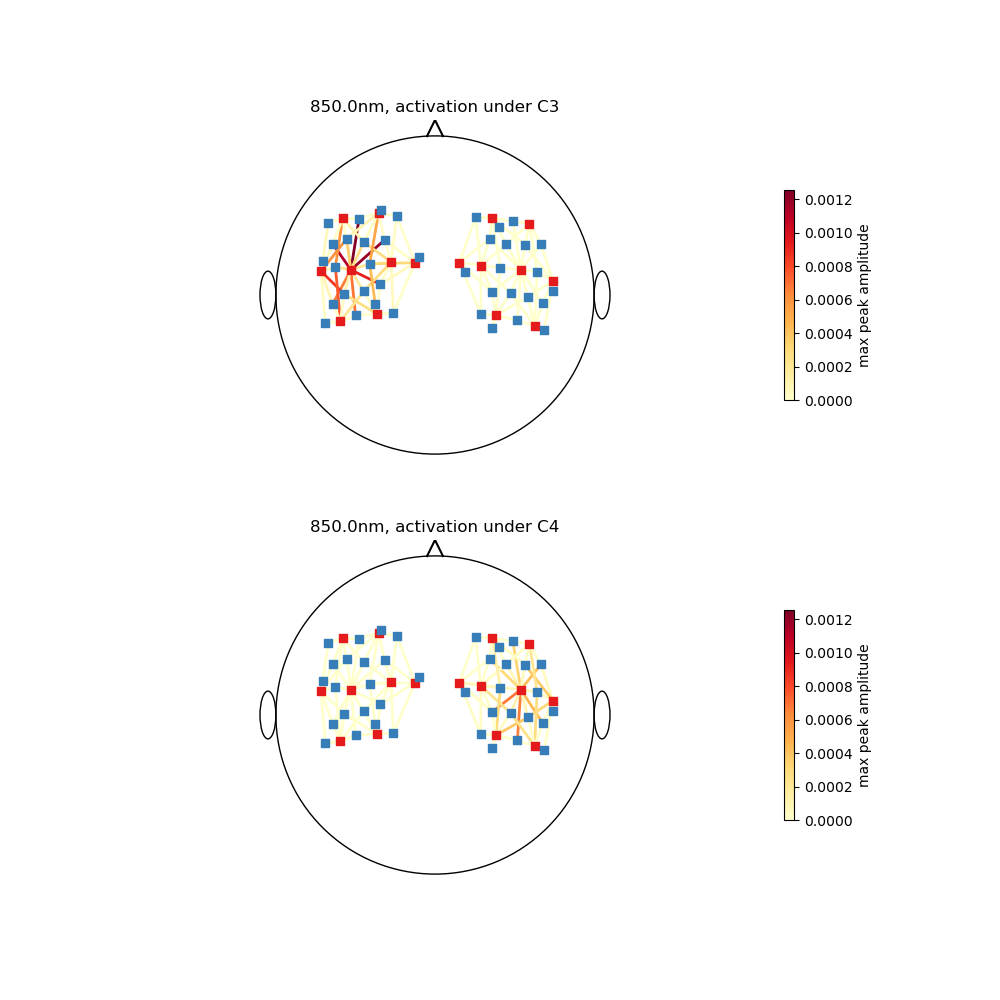

In [19]:
sim.build_fnirs_mixing_matrix()
display(sim.A_fnirs)
max_values = np.abs(sim.A_fnirs).max(dim=['channel', 'wavelength', 'chromo'])
display(max_values)
sim.plot_fnirs_topomap(wl_ndx=1)

### EEG


--- Building EEG mixing matrix ---
--- EEG mixing matrix built successfully ---


Magnitude,[[-0.0026585466232607316 -0.2171070857186602] [0.5216759790105812 -0.4621770925120861] [0.8638953951418868 -0.9102063819072498] [0.6014553567123617 -0.5797002864982294] [1.0 -0.2690634717131044] [0.4658125009716452 0.05975615233999592] [0.7500028311433184 0.11440111523099848] [0.7734965616566466 -0.19949870895601543] [0.3994104701238093 -0.11314327738484713] [0.7011201799389281 0.1658797628022997] [0.43065037687213126 0.3162032526944187] [0.09801062429714477 0.3894940653403114] [0.31593726361480406 0.3115562362610291] [0.44247466340792047 0.15405643471837593] [0.04666807565888338 0.2978986832719282] [-0.07388484276428109 0.2721322397500999] [-0.2157803335000142 0.456114992100586] [-0.1598854612421462 0.460600166064142] [-0.36015775797721583 0.4011276706976815] [-0.4905200000086953 0.16316416855554] [-0.31385707754256786 0.43269159447043304] [-0.036806798728174356 0.35043435828707664] [0.09174191439703645 0.24385897517641394] [-0.2805644915633852 0.11835906318690877] [-0.5032899891196134 0.11133643875727356] [-0.5123967114461186 -0.176069949402805] [-0.49233214259092734 -0.1139197235126566] [-0.19173613583699012 0.0393095043068442] [-0.3674804873300005 -0.23870461592484124] [-0.5220724583563305 -0.33050798510881696] [-0.4061858603286071 -1.0]]
Units,microvolt/(meter nanoampere)


Magnitude,[1.0 1.0]
Units,microvolt/(meter nanoampere)


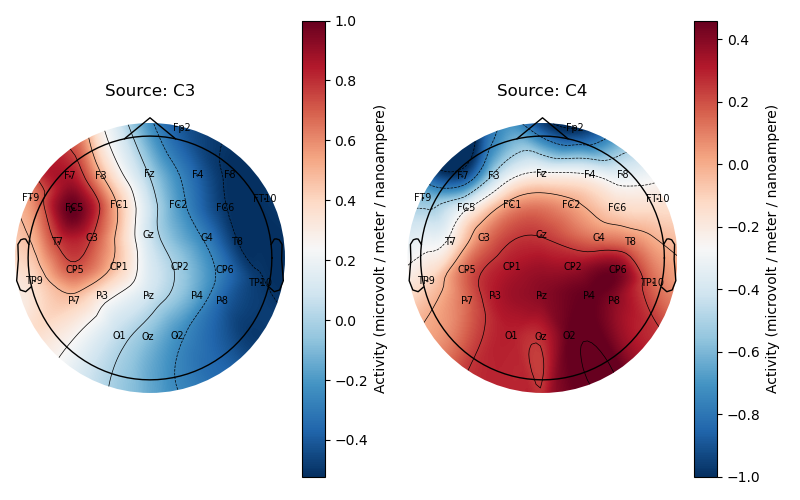

In [20]:
sim.build_eeg_mixing_matrix()
display(sim.A_eeg)
max_values = np.abs(sim.A_eeg).max(dim='channel')
display(max_values)
sim.plot_eeg_topomap(relative_limits=False)

## Stimuli Markers

Here we build the stimulus markers, defining the schedule of the simulated experiment. This is the way in which we incorporate temporal (When) co-modulation between modalities.

In [21]:
sim.build_shared_stimuli_marker(T_stim = 4.0 * units.seconds, 
                         T_rest_min = 6.0 * units.seconds, 
                         T_rest_max = 10.0 * units.seconds, 
                         min_stim_amp = 1.0, 
                         max_stim_amp = 1.0, 
                         order = 'random',
                         response_t= 0)

display(sim.stim)
display(sim.stim_with_jitter)


--- Building stimulus markers ---
Setting stimulus schedule in source configuration...
Source 'C3' schedule set with 2 trials of types ['right'].
Source 'C4' schedule set with 5 trials of types ['left'].
--- Stimulus markers built successfully, total trials = 7 ---


,onset,duration,value,trial_type
0,18.59,4.0,1.0,right
1,31.79,4.0,1.0,left
2,45.73,4.0,1.0,left
3,55.95,4.0,1.0,right
4,69.02,4.0,1.0,left
5,82.56,4.0,1.0,left
6,95.74,4.0,1.0,left


,onset,duration,value,trial_type
0,18.59,4.0,1.0,right
1,31.79,4.0,1.0,left
2,45.73,4.0,1.0,left
3,55.95,4.0,1.0,right
4,69.02,4.0,1.0,left
5,82.56,4.0,1.0,left
6,95.74,4.0,1.0,left


## Temporal Profile

### fNIRS


--- Building fNIRS temporal profiles ---
Setting shared temporal amp for source 'C3' to 1.0...
[1.0]
fNIRS temporal profile built for source 'C3', HbO scale: 1.0, HbR scale: -0.4.
Setting shared temporal amp for source 'C4' to 1.0...
[1.0]
fNIRS temporal profile built for source 'C4', HbO scale: 1.0, HbR scale: -0.4.
--- fNIRS temporal profiles built successfully ---


Magnitude,[[[0.0 -0.0] [0.0 -0.0]] [[0.0 -0.0] [0.0 -0.0]] [[0.0 -0.0] [0.0 -0.0]] ... [[0.0 -0.0] [0.0 -0.0]] [[0.0 -0.0] [0.0 -0.0]] [[0.0 -0.0] [0.0 -0.0]]]
Units,micromolar


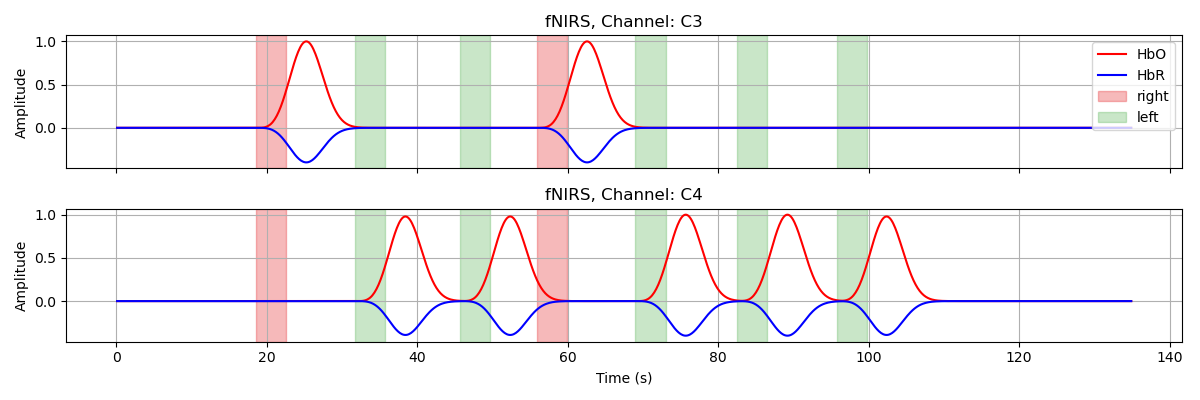

In [22]:
# Set fNIRS temporal properties for each source using the set_temporal_fnirs method of SourcesConfig
# sim.source_cfg.set_temporal_fnirs(name="C3", model="Gamma", model_params={'tau':0 * units.s, 
#                                                                           'sigma':3 * units.s, 
#                                                                           'T':3 * units.s}, 
#                                                                           hbr_hbo_ratio=-0.4)
# sim.source_cfg.set_temporal_fnirs(name="MotRH", model="Gamma", model_params={'tau':0 * units.s, 
#                                                                           'sigma':3 * units.s, 
#                                                                           'T':3 * units.s}, 
#                                                                           hbr_hbo_ratio=-0.4)
# sim.source_cfg.set_temporal_fnirs(name="DMN", model="Gamma", model_params={'tau':0 * units.s, 
#                                                                           'sigma':3 * units.s, 
#                                                                           'T':3 * units.s}, 
#                                                                           hbr_hbo_ratio=-0.4)
# sim.source_cfg.set_temporal_fnirs(name="Vis", model="Gamma", model_params={'tau':0 * units.s, 
#                                                                           'sigma':3 * units.s, 
#                                                                           'T':3 * units.s}, 
#                                                                           hbr_hbo_ratio=-0.4)

# Simpler temporal configuration for testing
sim.source_cfg.set_temporal_fnirs(name="C3", model="Gamma", model_params={'tau':0 * units.s, 
                                                                          'sigma':3 * units.s, 
                                                                          'T':3 * units.s}, 
                                                                          hbr_hbo_ratio=-0.4)

sim.source_cfg.set_temporal_fnirs(name="C4", model="Gamma", model_params={'tau':0 * units.s, 
                                                                          'sigma':3 * units.s, 
                                                                          'T':3 * units.s}, 
                                                                          hbr_hbo_ratio=-0.4)

sim.build_fnirs_source_temporal_profile()                                        

display(sim.s_fnirs_temporal)
plot_fnirs(sim.s_fnirs_temporal.transpose('source', 'chromo', 'time'), stim=sim.stim)

### EEG


--- Building EEG temporal profiles ---
Setting shared temporal amp for source 'C3' to 1.0...
EEG temporal profile built for source 'C3', frequency band: (8, 13) Hz.
Setting shared temporal amp for source 'C4' to 1.0...
EEG temporal profile built for source 'C4', frequency band: (8, 13) Hz.
--- EEG temporal profiles built successfully ---


Magnitude,[[0.004481706704095096 -0.009418569706227686] [-0.0033300709059111413 0.013629550825154518] [-0.003808790842582896 0.03489829611576809] ... [-0.4624491568713943 0.20290480921188384] [-0.4518873011148586 0.23948885229666234] [-0.4463781241241822 0.2639904467769929]]
Units,meter nanoampere


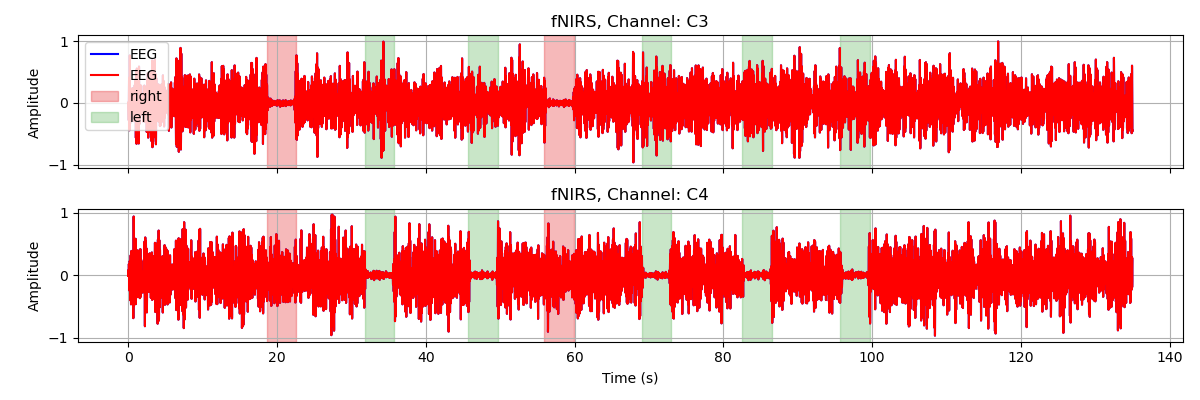

In [ ]:
# Set EEG temporal profiles using ERD model (The erd drop will be calculated based on the stim amplitude)
# sim.source_cfg.set_temporal_eeg(name="C3", model="ERD", model_params={'freq_band': (8, 12), 'ers_rebound_gain': .1},)
# sim.source_cfg.set_temporal_eeg(name="MotRH", model="ERD", model_params={'freq_band': (8, 12), 'ers_rebound_gain': .1},)
# sim.source_cfg.set_temporal_eeg(name="DMN", model="ERD", model_params={'freq_band': (8, 12), 'ers_rebound_gain': .1},)
# sim.source_cfg.set_temporal_eeg(name="Vis", model="ERD", model_params={'freq_band': (8, 12), 'ers_rebound_gain': .1},)

# Simpler temporal configuration for testing
sim.source_cfg.set_temporal_eeg(name="C3", model="ERD", model_params={'freq_band': (8, 13), 'ers_rebound_gain': .1},)
sim.source_cfg.set_temporal_eeg(name="C4", model="ERD", model_params={'freq_band': (8, 13), 'ers_rebound_gain': .1},)

# Build EEG source temporal profiles
sim.build_eeg_source_temporal_profile()
display(sim.s_eeg_temporal)

# Visualize EEG temporal profiles
eeg_hack = sim.s_eeg_temporal.expand_dims('chromo').assign_coords(chromo=['EEG'])
eeg_hack = xr.concat([eeg_hack, eeg_hack], dim='chromo')
plot_fnirs(eeg_hack, stim=sim.stim)

## Forward Model

### fNIRS


--- Applying fNIRS forward model ---
Combining fNIRS spatial and temporal profiles to get voxel-wise source activity...
--- fNIRS forward model applied successfully ---


Magnitude,[[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] ... [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [0.0 0.0 0.0 ... 0.0 0.0 0.0]]]
Units,dimensionless


Magnitude,[[[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] ... [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]]] [[[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] ... [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]] [[0.0 0.0 0.0 ... 0.0 0.0 0.0] [-0.0 -0.0 -0.0 ... -0.0 -0.0 -0.0]]]]
Units,micromolar


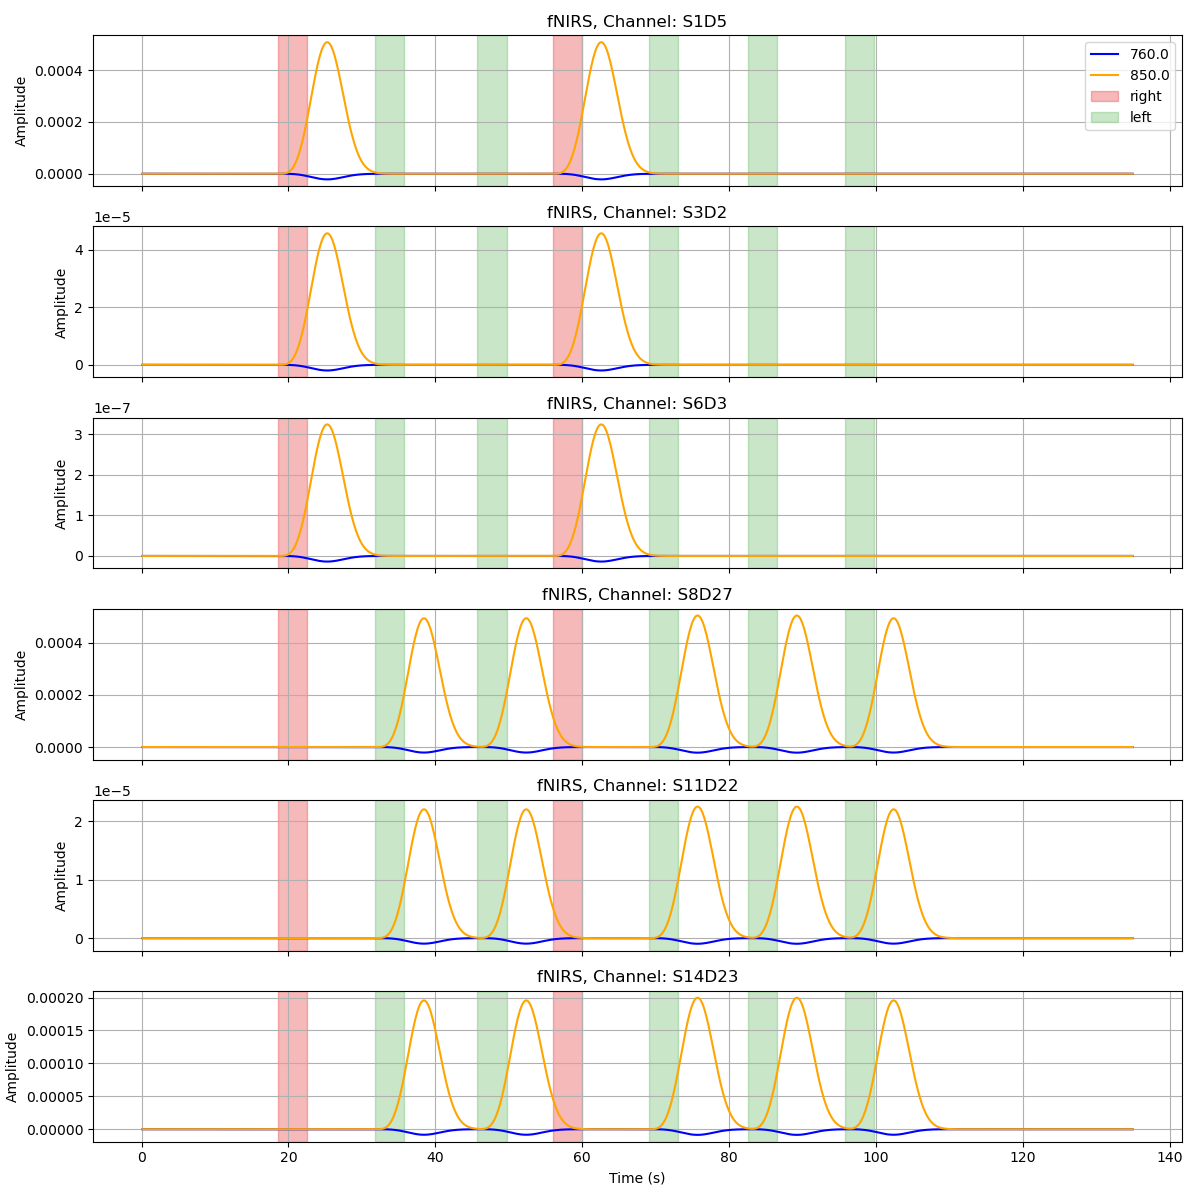

In [24]:
sim.apply_fnirs_forward_model()

display(sim.fnirs_sim_od)
display(sim.s_fnirs_voxel)
plot_fnirs(sim.fnirs_sim_od, stim=sim.stim, fmt=None, channels=fnirs_ch_plot)

### EEG


--- Applying EEG forward model ---
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 13 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 13.00 Hz
- Upper transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 14.62 Hz)
- Filter length: 825 samples (1.654 s)

--- EEG forward model applied successfully ---


Magnitude,[[1.8964616968636364e-08 -2.7522265194927363e-08 -7.058807626702765e-08 ... -3.994307494944325e-07 -4.7379152821590303e-07 -5.235544885483054e-07] [6.254170824207641e-08 -7.506235933407973e-08 -1.6910887120275032e-07 ... -3.1379266667226042e-06 -3.2439788940988967e-06 -3.3226616667443184e-06] [1.1629571370358867e-07 -1.4271991263798185e-07 -3.2719988482663324e-07 ... -5.470577340046045e-06 -5.695633256660936e-06 -5.859039198229285e-06] ... [5.524719969528531e-09 -1.887201848079806e-08 -6.458484120889485e-08 ... 1.1423109906446153e-06 1.0244336248468367e-06 9.5088011035691e-07] [7.091889440848898e-09 -2.5715701536535118e-08 -8.894965239101113e-08 ... 1.6391667819027461e-06 1.4746409492355544e-06 1.372114088509391e-06] [7.078966701427933e-08 -1.1446215691524425e-07 -3.1105515779053e-07 ... -1.3084435346206636e-07 -5.123821922152757e-07 -7.61950185173767e-07]]
Units,volt


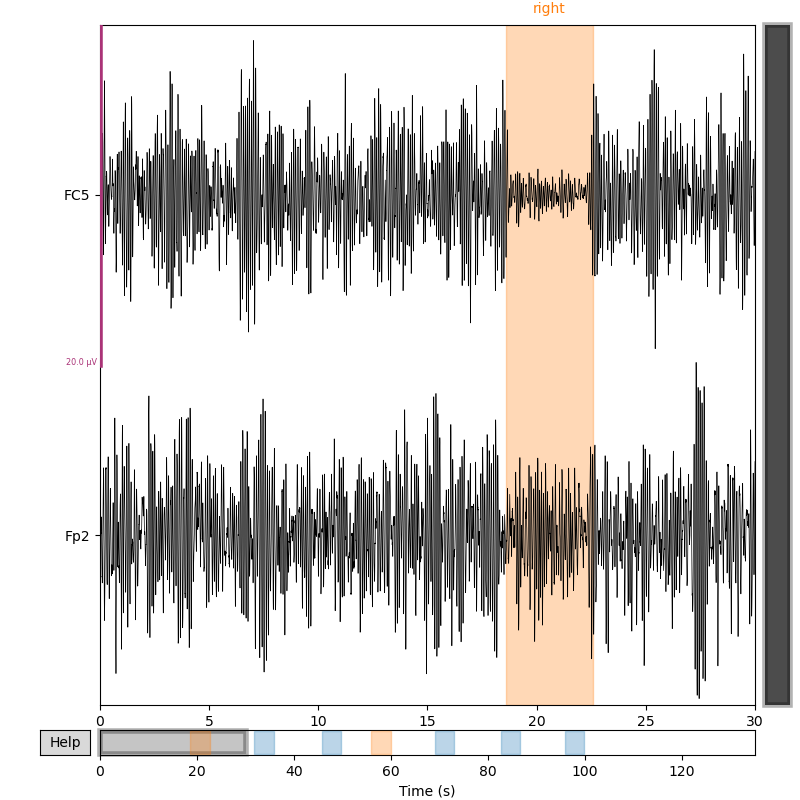

Effective window size : 4.105 (s)
Plotting power spectral density (dB=True).


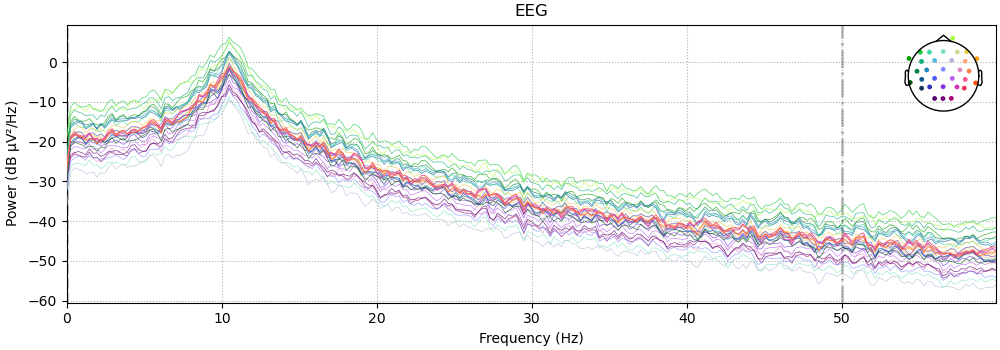

In [25]:
sim.apply_eeg_forward_model()

display(sim.eeg_sim)

# Get maximum channel activations
max_channels = sim.A_eeg.channel[abs(sim.A_eeg).argmax(dim='channel')].values.tolist()
plot_eeg(sim.eeg_sim_raw, plot_psd=True, fmax=60, duration=30, channels=max_channels, scalings=1e-5)

## Add Background

### fNIRS


--- Adding background fNIRS data ---
--- Background fNIRS data added successfully ---


Magnitude,[[[4.0481216441928515e-05 6.969458642309246e-05 6.452814610915001e-05 ... 6.474553013313644e-05 1.2695239763351732e-05 3.097014656704782e-05] [9.633437384840852e-05 0.00011685465255073924 9.817139538015371e-05 ... 9.845735873434154e-05 6.944568237870887e-05 0.00010398575558542714]] [[1.2239263192253686e-05 3.226455939065325e-05 3.073157847705541e-05 ... 4.4055000747879654e-05 2.38944152181568e-05 2.5124287501976858e-05] [6.0792679046768064e-05 9.251131108774764e-05 9.313732910204125e-05 ... 3.60961333690538e-05 1.5069188932839328e-05 9.390251405835147e-06]] [[1.7908433006974558e-06 1.3756351828651836e-05 1.4234612335725507e-05 ... 3.734575055392955e-05 1.915544912134708e-05 2.2284945166226686e-05] [3.068140908182483e-05 5.9690538263904056e-05 5.958644691749154e-05 ... 6.19229835446117e-06 -1.8195225963551833e-05 -2.1950013928455403e-05]] ... [[0.00013496455640721938 0.00014333694096895706 0.0001288712258642888 ... 6.750014813343893e-05 5.176700634479356e-05 8.472408842487014e-05] [0.00016300902439315182 0.0001700144778707195 0.00016058909661103885 ... 1.2422205999241547e-05 -1.0079006428790972e-05 3.9493737005316045e-05]] [[0.0001595988734862944 0.0001710012361051406 0.00017168357685478608 ... 4.229210260886202e-05 5.239198968656585e-06 4.830238675783811e-05] [0.00017515839724724678 0.0001949686158421425 0.00018598319477644963 ... -3.0274299821652427e-06 -2.074422183108819e-05 1.3662801069434887e-05]] [[1.3160295662233683e-05 1.6690724888474192e-05 1.818688618498911e-05 ... -1.475458457331845e-05 -2.138453290260982e-05 -1.3373670243930833e-05] [3.341662367204933e-05 3.889669635981324e-05 4.0413622048048224e-05 ... -2.2631845424821628e-05 -3.151188198315923e-05 -2.0687270930249576e-05]]]
Units,dimensionless


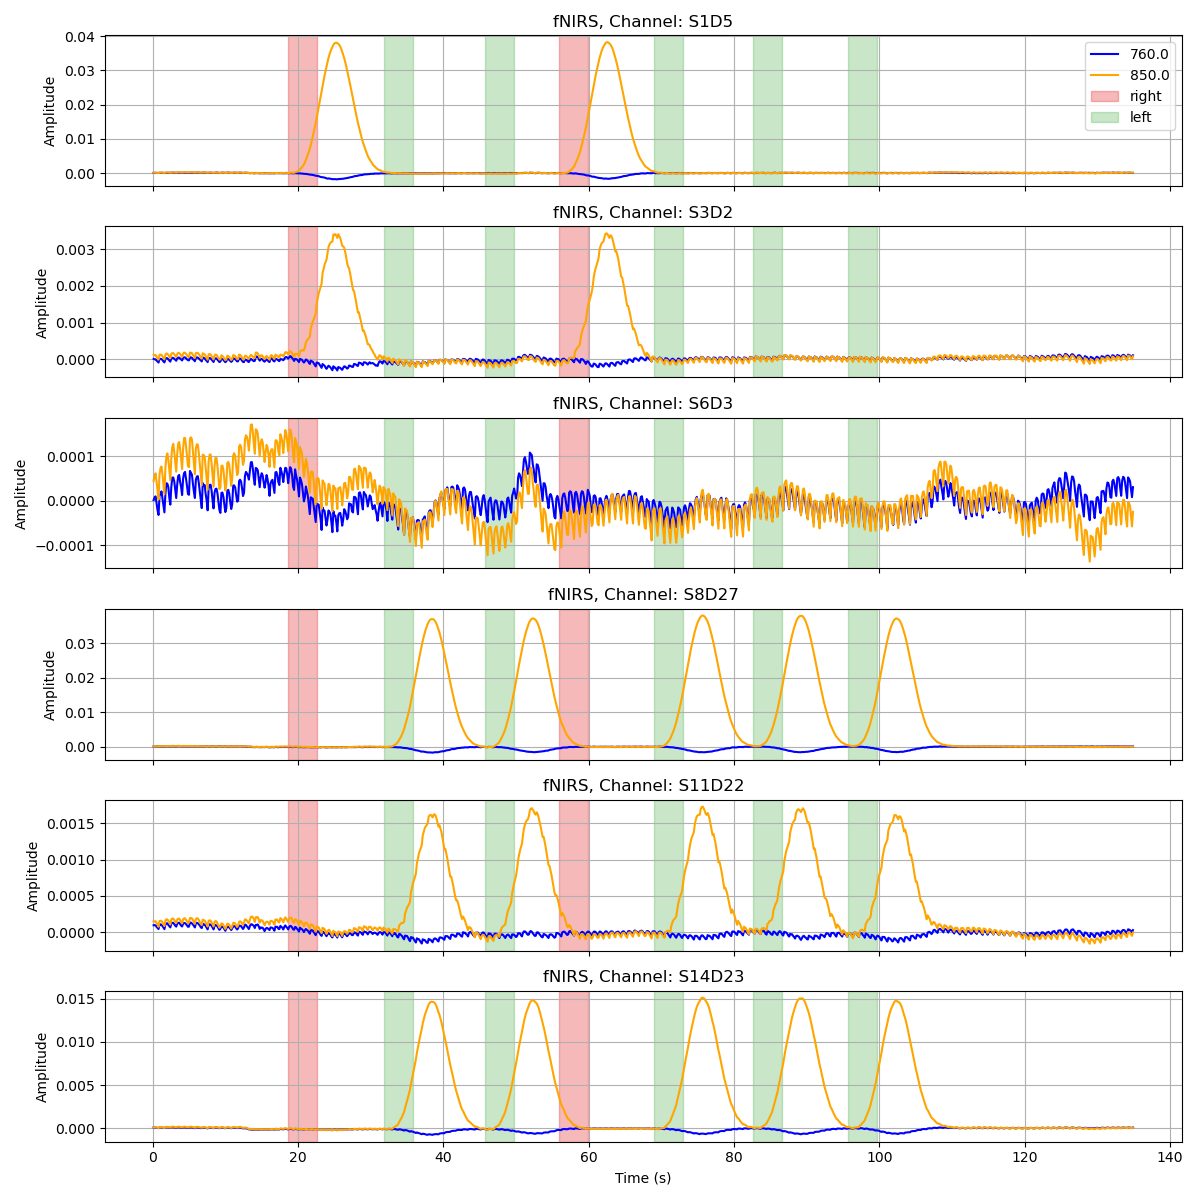

In [31]:
sim.add_background_fnirs(snr_db=50)
display(sim.fnirs_od)
plot_fnirs(sim.fnirs_od, stim=sim.stim, fmt=None, channels=fnirs_ch_plot)

### EEG


--- Adding background EEG data ---
--- Background EEG data added successfully ---


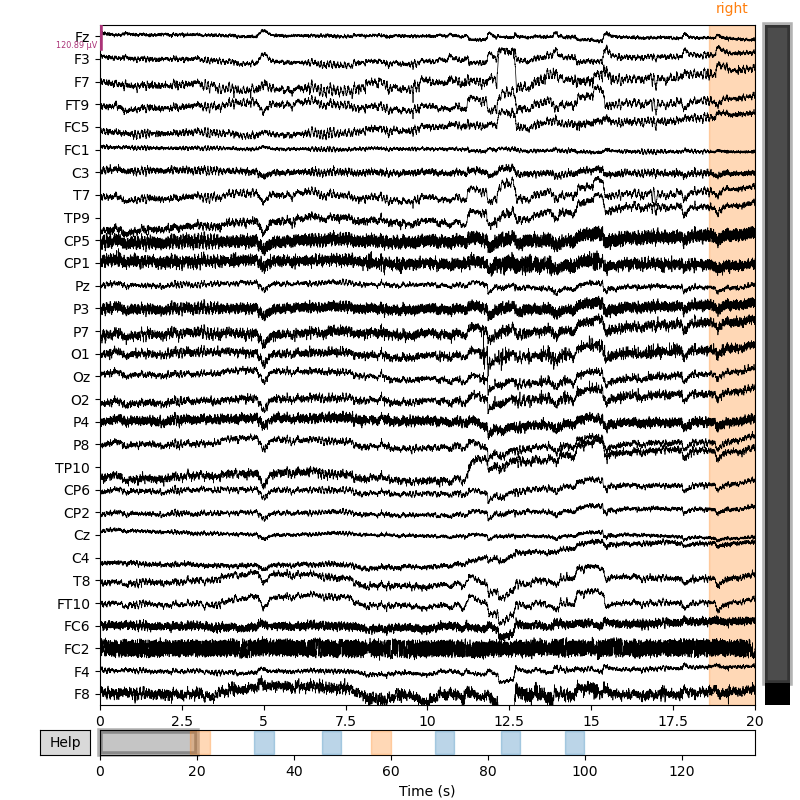

Effective window size : 4.105 (s)
Plotting power spectral density (dB=True).


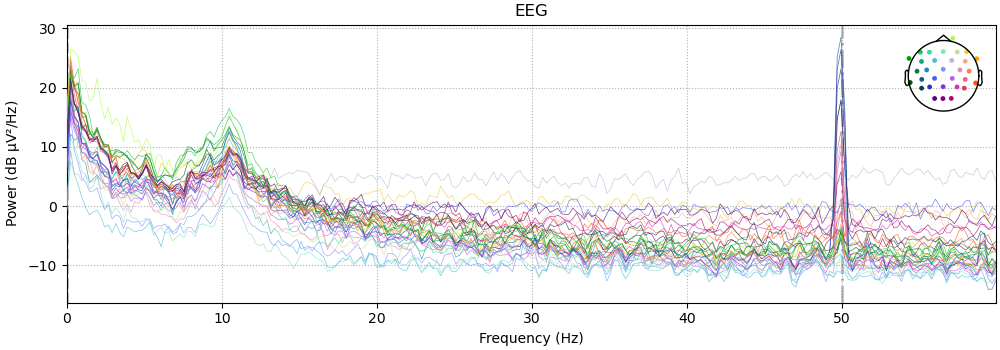

In [29]:
sim.add_background_eeg(snr_db=10)

plot_eeg(sim.eeg, plot_psd=True, fmax=60, duration=20)

## Run Full Pipeline

Intead of running the pipeline step by step, we can do it altogether.

### Via a Configuration File (WIP)

In [ ]:
# config_file = './config_simulation_simple.yaml'
# sim = SimulatefNIRSAndEEGData.run_full_pipeline(config_file,
#                                                 snr=10,
#                                                 verbose=True,
#                                                 seed=42)

# # Modify final SNR of simulated data
# snr = 10
# sim.add_background_fnirs(snr=snr)
# sim.add_background_eeg(snr=snr)

# # Visualize final simulated data
# fnirs_ch_plot = sim.fnirs_bg_rec['amp'].channel.values[::20]
# plot_fnirs(sim.fnirs_od, stim=sim.stim, fmt=None, channels=fnirs_ch_plot)
# plot_eeg(sim.eeg, plot_psd=True, fmax=60)

## Full Pipeline Part-by-Part

In [ ]:
# Define global paths
SUBJECTS_DIR = Path("/Users/guybrush/Documents/neurotech/ibs_lab/synthetic_DOT-EEG_pipeline/data")
subject = 'de179'
sub_dir = SUBJECTS_DIR / subject
fnirs_background_file = sub_dir / f'{subject}_rest1_nirs.snirf'  # fNIRS
eeg_background_file = sub_dir / f'{subject}_rest1_eeg_raw.fif'  # EEG

# Headmodel name (and files)
headmodel_name = 'colin27'  # 'colin27', 'icbm152, or 'individual'

# Montage file
montage_file = sub_dir / f'{subject}_fnirs_montage_global.tsv'

# Precomputed sensitivity files
sensitivity_fname = sub_dir / 'sensitivity_HMcolin27_fbrain29988_fscalp20096_fNIRSch116_EEGch31.hdf5'
eeg_forward_sol_fname = sub_dir / 'EEG_fwd_HMcolin27_fbrain29988_fscalp20096_fNIRSch116_EEGch31_fwd.fif'

# Initialize class
sim = SimulatefNIRSAndEEGData(subject=subject,
                              subjects_dir=SUBJECTS_DIR,
                              verbose=True)

# Load background data
sim.load_background_data(fnirs_file=fnirs_background_file, 
                         eeg_file=eeg_background_file,
                         rest_window=(5, 130))
fnirs_ch_plot = sim.fnirs_bg_rec['amp'].channel.values[::20]

# Build head model and fNIRS-EEG montage profile, the latter already aligned and snapped to scalp
sim.build_headmodel(head_model_name=headmodel_name)

sim.build_montage(montage_file=montage_file,
                  eeg_montage_name='standard_1020')

sim.build_sensitivity(sensitivity_fname=sensitivity_fname)
sim.build_leadfield(eeg_forward_sol_fname=eeg_forward_sol_fname,
                    conductivity=(0.3, 0.006, 0.3),
                    overwrite=True)

plot_fnirs(sim.fnirs_bg_rec['od'], channels=fnirs_ch_plot, stim=sim.rest_stim, fmt=sim.fmt)

In [ ]:
sim.init_source_config(names=['C3', 'C4'],
                       spatial_amps=1.0,
                       temporal_amps=[1.0, 1.0],
                       trial_types=['right', 'left'],)

sim.source_cfg.set_spatial(name="C3", selector="landmark", loc="C3")
sim.source_cfg.set_spatial(name="C4", selector="landmark", loc="C4")

# Build source spatial profiles
sim.build_shared_source_spatial_profile()
sim.build_fnirs_source_spatial_profile()
sim.build_eeg_source_spatial_profile()

# Mixing matrices 
sim.build_fnirs_mixing_matrix()
sim.build_eeg_mixing_matrix()

# Scalp plots
sim.plot_fnirs_topomap(wl_ndx=1)
sim.plot_eeg_topomap(relative_limits=False)

In [ ]:
# Stimuli markers
sim.build_shared_stimuli_marker(T_stim = 10.0 * units.seconds, 
                         T_rest_min = 6.0 * units.seconds, 
                         T_rest_max = 10.0 * units.seconds, 
                         min_stim_amp = 0.8, 
                         max_stim_amp = 1.0, 
                         order = 'random',
                         response_t= 0.0)

# Source temporal profile 
sim.source_cfg.set_temporal_fnirs(name="C3", model="Gamma", model_params={'tau':0 * units.s, 
                                                                          'sigma':3 * units.s, 
                                                                          'T':3 * units.s}, 
                                                                          hbr_hbo_ratio=-0.4)
sim.source_cfg.set_temporal_fnirs(name="C4", model="GaussianKernelsWithTails", 
                                  model_params={'t_pre':-1 * units.s, 
                                                't_post': sim.T_stim + 5 * units.s, 
                                                't_delta': .3 * units.s,
                                                't_std': .3 * units.s}, 
                                  hbr_hbo_ratio=-0.4)
sim.build_fnirs_source_temporal_profile()

# Visualize source temporal profiles
plot_fnirs(sim.s_fnirs_temporal.transpose('source', 'chromo', 'time'), stim=sim.stim)

In [ ]:
sim.source_cfg.set_temporal_eeg(name="C3", model="ERD", model_params={'freq_band': (8, 12), 'ers_rebound_gain': .1},)
sim.source_cfg.set_temporal_eeg(name="C4", model="ERD", model_params={'freq_band': (8, 12), 'ers_rebound_gain': .1},)
sim.build_eeg_source_temporal_profile()

eeg_hack = sim.s_eeg_temporal.expand_dims('chromo').assign_coords(chromo=['EEG'])
eeg_hack = xr.concat([eeg_hack, eeg_hack], dim='chromo')
plot_fnirs(eeg_hack, stim=sim.stim)

# Apply forward models
sim.apply_fnirs_forward_model()
sim.apply_eeg_forward_model()

# Get maximum channel activations
max_channels = sim.A_eeg.channel[abs(sim.A_eeg).argmax(dim='channel')].values.tolist()
plot_eeg(sim.eeg_sim_raw, plot_psd=True, fmax=60, duration=60, channels=max_channels, scalings=1e-5)

In [ ]:
# Add background noise with specific SNR
snr_fnirs_db = -10
snr_eeg_db = 20
sim.add_background_fnirs(snr_db=snr_fnirs_db)
sim.add_background_eeg(snr_db=snr_eeg_db)

# Visualize final simulated data
eeg_chs_to_plot = ['FC1', 'T7', 'Oz', 'C4', 'CP2']
## fNIRS
max_chs_fnirs = sim.A_fnirs.channel[abs(sim.A_fnirs.sel(wavelength=850, chromo='HbO')).argmax(dim=['channel'])].values
plot_fnirs(sim.fnirs_od, stim=sim.stim, fmt=None, channels=max_chs_fnirs)

# EEG raw
max_chs_eeg = sim.A_eeg.channel[abs(sim.A_eeg).argmax(dim='channel')].values.tolist()
plot_eeg(sim.eeg, plot_psd=True, fmax=60, duration=60, channels=max_chs_eeg, scalings=1e-5)

# EEG preprocessed
fmin, fmax = sim.source_cfg[1].temporal_eeg.model_params['freq_band']
x = sim.eeg.copy().pick(picks='eeg')
x.filter(l_freq=fmin, h_freq=fmax, fir_design='firwin', phase='zero')
x.resample(sfreq=100, npad="auto")
# x.pick(picks=max_chs_eeg)
plot_eeg(x, plot_psd=True, fmax=40, duration=60, channels=max_chs_eeg, scalings=1e-4)

## Block Average Analysis

### Small Preprocessing

In [ ]:
y = sim.fnirs_od.copy()

# Concentration changes
dpf = xr.DataArray([6, 6], dims="wavelength", coords={"wavelength": y.wavelength})
y = cedalion.nirs.od2conc(y, sim.montage, dpf, spectrum="prahl")

# Bandpass filter
fmin = 0.01 * units.Hz
fmax = 0.6 * units.Hz
y = cedalion.sigproc.frequency.freq_filter(y, fmin, fmax)

In [ ]:
stim = sim.stim
trial_types = stim.trial_type.unique().tolist()
duration = stim.duration.values.mean()
T_rest_min = sim.T_rest_min.magnitude
before = 5 * units.s
after = (duration + T_rest_min) * units.s

# 1) Split into epochs
epochs = y.cd.to_epochs(
    stim,
    trial_types,
    before=before,
    after=after,
)

# 2) Baseline removal
baseline = epochs.sel(reltime=(epochs.reltime < 0)).mean("reltime")
epochs -= baseline

# 3) Block average conditions
y_avg = epochs.groupby("trial_type").mean("epoch")
y_avg = y_avg.rename({'reltime': 'time'})

In [ ]:
# Plot block averages (this can be tweaked to your liking)
%matplotlib inline

fnirs_ch_plot = [ch for ch in y.channel.data]

fnirs_avg_sub = y_avg.sel(trial_type=trial_types, channel=fnirs_ch_plot)
ymax = fnirs_avg_sub.max().pint.dequantify().values
ymin = fnirs_avg_sub.min().pint.dequantify().values

ncols = 5
nrows = int(np.ceil(len(fnirs_ch_plot) / ncols))
f, ax = plt.subplots(nrows, ncols, figsize=(nrows, 12*ncols))
ax = ax.flatten()
for i_ch, ch in enumerate(fnirs_ch_plot):
    for ls, trial_type in zip(["-", "--"], trial_types):
        ax[i_ch].plot(
            fnirs_avg_sub.time,
            fnirs_avg_sub.sel(chromo="HbO", trial_type=trial_type, channel=ch),
            "r",
            lw=2,
            ls=ls,
        )
        ax[i_ch].plot(
            fnirs_avg_sub.time,
            fnirs_avg_sub.sel(chromo="HbR", trial_type=trial_type, channel=ch),
            "b",
            lw=2,
            ls=ls,
        )
    ax[i_ch].grid(1)
    ax[i_ch].set_title(ch)
    ax[i_ch].set_ylim(ymin, ymax)

# add legend
legends = np.array([[f"HbO {t}",f"HbR {t}"] for t in trial_types]).flatten().tolist()
ax[0].legend(legends)
plt.suptitle('Single-finger Sitting/Walking Condition')
plt.tight_layout()